Sentimen Analisis Pernyataan Prabowo tentang "Orang Desa Tidak Pakai Dolar" Menggunakan Algoritma Logistik Regression
---

#PreProcessing


##Data Cleaning

In [ ]:
#Install library
!pip install openpyxl requests

In [ ]:
#Install Sastrawi untuk stemming
!pip install openpyxl requests PySastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 6.8 MB/s eta 0:00:00


In [ ]:
#Import Library
import re
import json
import requests
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [ ]:
#Inisiasi Stemming
factory = StemmerFactory()
stemmer = factory.create_stemmer()
print("Stemmer Sastrawi siap")

Stemmer Sastrawi siap


###Upload dataset dan kamus


In [ ]:
#Upload File dataset dan kamus
from google.colab import files
uploaded = files.upload()

Saving DatasetSentimen.csv to DatasetSentimen.csv
Saving kamuskatabaku.xlsx to kamuskatabaku.xlsx


In [ ]:
#Load Kamus kata baku
df_kamus = pd.read_excel('kamuskatabaku.xlsx')

# Pastikan nama kolom benar
print("Kolom kamus:", df_kamus.columns.tolist())
print(f"Jumlah entri kamus kata baku: {len(df_kamus)}")
print(df_kamus.head())

# Konversi ke dictionary  {tidak_baku: kata_baku}
kamus_baku = dict(zip(
    df_kamus.iloc[:, 0].astype(str).str.lower().str.strip(),
    df_kamus.iloc[:, 1].astype(str).str.lower().str.strip()
))

# Tambahkan kamus manual
kamus_manual = {
    # Negasi — normalisasi ejaan
    'gak'    : 'tidak',
    'ga'     : 'tidak',
    'ngak'   : 'tidak',
    'nggak'  : 'tidak',
    'gk'     : 'tidak',
    'gkk'    : 'tidak',
    'tdk'    : 'tidak',
    'ndak'   : 'tidak',

    # Temporal
    'sdh'    : 'sudah',
    'sblm'   : 'sebelum',
    'spt'    : 'seperti',
    'krn'    : 'karena',
    'karna'  : 'karena',

    # Kata ganti
    'gw'     : 'saya',
    'gue'    : 'saya',
    'lo'     : 'kamu',
    'lu'     : 'kamu',
    'elu'    : 'kamu',

    # Entitas khusus dataset ini
    'indo'   : 'indonesia',
    'ri'     : 'indonesia',
    'wowo'   : 'prabowo',
    'pak'    : 'bapak',

    # Noise umum
    'wkwkwk' : '',
    'wkwk'   : '',
    'haha'   : '',
    'hehe'   : '',
    'hihi'   : '',
    'lol'    : '',
    'wtf'    : '',
    'amp'    : '',
    'br'     : '',
    'brbr'   : '',
}

# Gabungkan: kamus_baku + kamus_manual
kamus_gabungan = {**kamus_baku, **kamus_manual}
print(f"\nTotal entri kamus gabungan: {len(kamus_gabungan)}")

Kolom kamus: ['tidak_baku', 'kata_baku']
Jumlah entri kamus kata baku: 15185
  tidak_baku kata_baku
0       woww       wow
1      aminn      amin
2        met   selamat
3     netaas   menetas
4    keberpa  keberapa

Total entri kamus gabungan: 4360


###Load Stopword dari github

In [ ]:
#LOAD STOPWORD DARI GITHUB
BASE_URL = "https://raw.githubusercontent.com/ArhamZaldin/Kamus-Custom-Preprocessing-Analisis-Sentimen-Indonesia/main/"

def ambil_json(nama_file):
    """Ambil file JSON dari GitHub dan return sebagai set/dict."""
    try:
        resp = requests.get(BASE_URL + nama_file, timeout=10)
        resp.raise_for_status()
        data = resp.json()
        if isinstance(data, list):
            return set(data)
        elif isinstance(data, dict):
            return data
    except Exception as e:
        print(f"[WARNING] Gagal ambil {nama_file}: {e}")
        return set()

# Ambil stopword dari GitHub
stopword_github = ambil_json('custom-stopwords.json')

# Ambil daftar kata negasi (untuk DIKECUALIKAN dari stopword)
negasi_github   = ambil_json('negation-words.json')

print(f"Stopword dari GitHub  : {len(stopword_github)} kata")
print(f"Kata negasi (dijaga)  : {len(negasi_github)} kata")

Stopword dari GitHub  : 163 kata
Kata negasi (dijaga)  : 12 kata


### **Susun Stopword Final**

---

⚠️ **ATURAN UTAMA:**  
Kata negasi **TIDAK BOLEH** masuk ke dalam daftar *stopword* dalam kondisi apapun. Menghapus kata negasi akan membalikkan makna sentimen seluruh kalimat secara fatal.

**Ilustrasi Kesalahan:**
*   **Input:** `"tidak parah"` (Sentimen Positif/Netral)
*   **Proses:** Hapus *stopword* `"tidak"`
*   **Output:** `"parah"` (Sentimen Negatif) &rarr; **SALAH TOTAL**

**Kata Negasi yang WAJIB dijaga:**
`tidak`, `bukan`, `jangan`, `belum`, `tanpa`, `tak`, `anti`, `non`

In [ ]:
KATA_NEGASI_WAJIB = {
    'tidak', 'bukan', 'jangan', 'belum', 'tanpa',
    'tak', 'anti', 'non', 'tiada', 'mustahil'
}

# Stopword manual dibuat khusus untuk konteks dataset ini
stopword_manual = {
    # Partikel & konjungsi umum
    'yang', 'di', 'ke', 'dari', 'dan', 'dengan', 'untuk', 'pada',
    'ini', 'itu', 'adalah', 'atau', 'oleh', 'ada', 'juga',
    'akan', 'tapi', 'bisa', 'aja', 'nih', 'sih', 'deh', 'dong',
    'kah', 'lah', 'pun', 'nya',
    'ya', 'yah', 'iya', 'oke', 'ok', 'oh', 'ah', 'eh', 'wah',

    # Sapaan
    'hai', 'hei', 'kak', 'mas', 'bang', 'bro', 'sis',

    # Kata ganti (setelah normalisasi)
    'saya', 'aku', 'kamu', 'dia', 'mereka', 'kita', 'kami',

    # Demonstratif & lokatif
    'sana', 'sini', 'situ', 'tersebut',

    # Aspek waktu netral
    'pernah', 'sedang', 'lagi', 'sudah',

    # Konjungsi kondisional & kausal
    'jika', 'kalau', 'bila', 'maka', 'agar', 'supaya',
    'namun', 'tetapi', 'melainkan', 'padahal', 'meskipun',
    'karena', 'sebab', 'sehingga', 'akibat',

    # Kopula
    'jadi', 'menjadi', 'ialah', 'yaitu', 'yakni',
    'demikian', 'begitu', 'seperti', 'bagaikan',

    #Kata umum bermasalah di InSet Lexicon
    'siapa', 'banyak', 'semua', 'apa', 'coba',
    'ikut', 'usah', 'bikin', 'orang', 'ajar',
}

# Pastikan stopword_github dikonversi ke set jika tipenya dict
stopword_github_set = set(stopword_github.keys()) if isinstance(stopword_github, dict) else set(stopword_github)

# Gabungkan stopword manual + GitHub
stopword_gabungan = stopword_manual | stopword_github_set

# Pastikan kata negasi TIDAK ada di stopword
stopword_final = stopword_gabungan - KATA_NEGASI_WAJIB

print(f"Stopword manual       : {len(stopword_manual)} kata")
print(f"Stopword GitHub       : {len(stopword_github_set)} kata")
print(f"Stopword gabungan     : {len(stopword_gabungan)} kata")
print(f"Stopword final (aman) : {len(stopword_final)} kata")

print("\nVerifikasi — kata negasi masih ada di stopword?")
for neg in sorted(KATA_NEGASI_WAJIB):
    status = 'BAHAYA' if neg in stopword_final else 'aman'
    print(f"  '{neg:10}' → {status}")

Stopword manual       : 92 kata
Stopword GitHub       : 163 kata
Stopword gabungan     : 248 kata
Stopword final (aman) : 248 kata

Verifikasi — kata negasi masih ada di stopword?
  'anti      ' → aman
  'belum     ' → aman
  'bukan     ' → aman
  'jangan    ' → aman
  'mustahil  ' → aman
  'non       ' → aman
  'tak       ' → aman
  'tanpa     ' → aman
  'tiada     ' → aman
  'tidak     ' → aman


### **Fungsi Cleaning Utama**

---

Fungsi ini merupakan jantung dari proses pra-pemrosesan data teks. Setiap baris data akan melewati tahapan berikut secara berurutan:

1.  **Guard:** Memastikan teks tidak kosong atau bernilai `NaN`.
2.  **Case Folding:** Mengubah semua huruf menjadi kecil (lowercase).
3.  **Hapus URL:** Menghilangkan tautan website (http/www).
4.  **Hapus Mention & Hashtag:** Membersihkan username (@) dan tagar (#).
5.  **Hapus Emoji & Non-ASCII:** Menghilangkan karakter khusus dan ikon.
6.  **Hapus Tanda Baca & Angka:** Hanya menyisakan karakter huruf.
7.  **Normalisasi Spasi:** Menghapus spasi ganda atau berlebih.
8.  **Normalisasi Kata:** Mengubah kata tidak baku menjadi baku menggunakan `kamus_gabungan`.
9.  **Stopword Removal:** Menghapus kata umum, namun tetap **menjaga kata negasi** agar makna tidak berubah.
10. **Stemming (Sastrawi)**: potong ke kata dasar.
11. **Duplikasi**: Menghapus duplikasi sebelum cleaning.
12. **Baris kosong**: Hapus baris kosong setelah cleaning.
13. **Hapus isi 1 kata**: Hapus baris yang isinya 1 kata setelah cleaning.

In [ ]:
def bersihkan_teks(teks):

    # a. Guard
    if pd.isna(teks) or str(teks).strip() == '':
        return ''

    # b. Case folding
    teks = str(teks).lower()

    # c. Hapus URL
    teks = re.sub(r'http\S+|www\S+', '', teks)

    # d. Hapus mention dan hashtag
    teks = re.sub(r'@\w+', '', teks)
    teks = re.sub(r'#\w+', '', teks)

    # e. Hapus emoji & karakter non-ASCII
    teks = teks.encode('ascii', 'ignore').decode('ascii')

    # f. Hapus tanda baca & angka (jaga huruf dan spasi)
    teks = re.sub(r'[^a-z\s]', '', teks)

    # g. Normalisasi spasi berlebih
    teks = re.sub(r'\s+', ' ', teks).strip()

    # h. Normalisasi kata tidak baku per kata
    kata_kata = teks.split()
    kata_kata = [kamus_gabungan.get(k, k) for k in kata_kata]

    # i. Stopword removal
    #    Panjang minimum 2 karakter agar sisa "k", "a" dll tidak masuk
    kata_kata = [
        k for k in kata_kata
        if k not in stopword_final and len(k) > 1
    ]

    # j. Stemming — potong kata ke bentuk dasarnya
    kata_kata = [stemmer.stem(k) for k in kata_kata]

    return ' '.join(kata_kata)

###Jalankan Data Cleaning

In [ ]:
df = pd.read_csv('DatasetSentimen.csv')
print(f"Dataset dimuat: {len(df)} baris")

# hapus baris duplikat sebelum cleaning
sebelum_dup = len(df)
df = df.drop_duplicates(subset='text').reset_index(drop=True)
sesudah_dup = len(df)

# Terapkan fungsi cleaning
print("Menjalankan cleaning...")
df['text_clean'] = df['text'].apply(bersihkan_teks)

# Hapus baris kosong hasil cleaning
sebelum_kosong = len(df)
df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
sesudah_kosong = len(df)

# Hapus baris yang hasil setelah cleaning hanya 1 kata
sebelum_1kata = len(df)
df = df[df['text_clean'].str.split().str.len() >= 2].reset_index(drop=True)
sesudah_1kata = len(df)

Dataset dimuat: 11163 baris
Menjalankan cleaning...


###LAPORAN & SIMPAN HASIL

In [ ]:
print("\n" + "=" * 55)
print("  LAPORAN DATA CLEANING")
print("=" * 55)
print(f"  Baris awal              : {sebelum_dup:,}")
print(f"  Baris duplikat dihapus  : {sebelum_dup - sesudah_dup:,}")
print(f"  Baris kosong dihapus    : {sebelum_kosong - sesudah_kosong:,}")
print(f"  Baris 1 kata dihapus    : {sebelum_1kata - sesudah_1kata:,}")
print(f"  Baris akhir (bersih)    : {sesudah_1kata:,}")
print("=" * 55)

print("\n  CONTOH HASIL (10 baris pertama):")
print("-" * 55)
for i, row in df.head(10).iterrows():
    print(f"  [{i+1}] SEBELUM : {str(row['text'])[:65]}")
    print(f"       SESUDAH : {str(row['text_clean'])[:65]}")
    print()

# Simpan hasil cleaning
df.to_csv('dataset_clean.csv', index=False)
print("File disimpan: dataset_clean.csv")
print("Lanjut ke: 02_labeling.py")

# Download file
files.download('dataset_clean.csv')


  LAPORAN DATA CLEANING
  Baris awal              : 11,163
  Baris duplikat dihapus  : 342
  Baris kosong dihapus    : 50
  Baris 1 kata dihapus    : 476
  Baris akhir (bersih)    : 10,295

  CONTOH HASIL (10 baris pertama):
-------------------------------------------------------
  [1] SEBELUM : presiden terburuk sepanjnag sejarah asli parah
       SESUDAH : presiden buruk sepanjnag sejarah asli parah

  [2] SEBELUM : banyak orang yang pintar ituu di sana tapi semua ikut ikutan bego
       SESUDAH : pintar ikut bego demi jawab

  [3] SEBELUM : siapa yg pilih wowo kemarin
       SESUDAH : pilih prabowo kemarin

  [4] SEBELUM : ulah si prabowo karena ada dendam pribadi hancurkan indo membuat 
       SESUDAH : ulah prabowo dendam pribadi hancur indonesia buat indonesia dalam

  [5] SEBELUM : kalau saya yakin yg maha kuasa cuma beri waktu untuk para korupsi
       SESUDAH : yakin maha kuasa cuma beri waktu para korupsi rasa kuasa dulu bel

  [6] SEBELUM : seharusnya minta maaf dulu karena

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Gabungkan datasetManual


In [ ]:
!pip install pandas openpyxl

In [1]:
#Masukan semua dataset
from google.colab import files
uploaded = files.upload()

Saving dataset_clean_manual.csv to dataset_clean_manual.csv


In [2]:
import pandas as pd
import numpy as np

In [3]:
nama_file_csv = 'dataset_clean_manual.csv'
df_gabungan = pd.read_csv(nama_file_csv)

print(f"File {nama_file_csv} berhasil dimuat.")
print(f"Total baris: {len(df_gabungan)}")

# Menampilkan 5 baris pertama
display(df_gabungan.head())

File dataset_clean_manual.csv berhasil dimuat.
Total baris: 10295


,id,text,text_clean,label_inset_lexicon,label_manual,catatan
0,10101,mending gua aja dah yg jadi presiden,mending gua saja presiden,Negatif,Negatif,NaN
1,3001,ternyata sama wakilnya,nyata sama wakil,Netral,Netral,NaN
2,6886,hore dolar naik lagi indonesia hebat,hore dolar naik indonesia hebat,Netral,Negatif,NaN
3,10007,untung dulu gua gak milih dia,untung dulu gua tidak pilih,Negatif,Negatif,NaN
4,3300,ini contoh manusia sakitbrjelas kan,contoh manusia sakitbrjelas,Positif,Negatif,NaN


In [4]:
# Urutkan kembali berdasarkan 'id' supaya rapi (id dibuat sejak
# tahap pembagian, jadi urutan asli sebelum diacak bisa dikembalikan)
df_gabungan = df_gabungan.sort_values('id').reset_index(drop=True)

print(f"Total baris setelah gabung: {len(df_gabungan)}")
print(f"Kolom: {df_gabungan.columns.tolist()}")

Total baris setelah gabung: 10295
Kolom: ['id', 'text', 'text_clean', 'label_inset_lexicon', 'label_manual', 'catatan']


In [5]:
# 1. Validasi — cek baris yang label_manual-nya masih kosong
kosong = df_gabungan[
    df_gabungan['label_manual'].isna() |
    (df_gabungan['label_manual'].astype(str).str.strip() == '')
]
print(f"\n⚠️  Baris dengan label_manual kosong: {len(kosong)}")
if len(kosong) > 0:
    print("   Daftar baris yang masih perlu diisi (ID, Text, Clean, Label):")
    display(kosong[['id', 'text', 'text_clean', 'label_manual']])
    print(f"\n   👉 Isi label_manual untuk {len(kosong)} baris di atas sebelum melanjutkan.")
else:
    print("✅ Semua baris sudah terisi label_manual.")

# 2. Cek nilai unik di label_manual — harus cuma 3: Positif, Negatif, Netral
print(f"\nNilai unik di label_manual (cek typo/inkonsistensi):")
print(df_gabungan['label_manual'].value_counts())

# 3. Cek id duplikat
id_duplikat = df_gabungan[df_gabungan.duplicated(subset='id', keep=False)]
print(f"\n⚠️  Baris dengan id duplikat: {len(id_duplikat)}")


⚠️  Baris dengan label_manual kosong: 6
   Daftar baris yang masih perlu diisi (ID, Text, Clean, Label):


,id,text,text_clean,label_manual
1186,1187,mending joget ajabrdaripada pidato,mending joget ajabrdaripada pidato,NaN
2154,2155,ngomong opo wok wok gj,omong opo wok wok gj,NaN
5160,5161,pintar kamu dek pasti ke prang tua mu bangga t...,pintar dek pasti prang tua bangga telah lahir ...,NaN
5994,5995,presiden apa kyak bgini bicaranya ngawuur sedi...,presiden kayak begini bicara ngawuur sediih,NaN
8762,8763,berarti gara2 kamu ini,arti gara,NaN
8935,8936,dikira rakyat di desa desa dongo.\nastaga naga...,kira rakyat desa desa dongo astaga naga baru k...,



   👉 Isi label_manual untuk 6 baris di atas sebelum melanjutkan.

Nilai unik di label_manual (cek typo/inkonsistensi):
label_manual
Negatif    8342
Netral     1486
Positif     461
              1
Name: count, dtype: int64

⚠️  Baris dengan id duplikat: 0


In [6]:
label_manual_baru = {
    1187: 'Positif',
    2155: 'Negatif',
    5161: 'Positif',
    5995: 'Negatif',
    8763: 'Netral',
    8936: 'Negatif',
}

for id_baris, label in label_manual_baru.items():
    df_gabungan.loc[df_gabungan['id'] == id_baris, 'label_manual'] = label

# Verifikasi — pastikan sudah tidak ada lagi yang kosong
kosong_setelah_isi = df_gabungan[
    df_gabungan['label_manual'].isna() |
    (df_gabungan['label_manual'].astype(str).str.strip() == '')
]
print(f"Baris masih kosong setelah diisi manual: {len(kosong_setelah_isi)}")

if len(kosong_setelah_isi) == 0:
    print("✅ Semua baris sudah terisi label_manual, siap lanjut ke standarisasi label.")
else:
    display(kosong_setelah_isi[['id', 'text', 'text_clean', 'label_manual']])

Baris masih kosong setelah diisi manual: 0
✅ Semua baris sudah terisi label_manual, siap lanjut ke standarisasi label.


In [7]:
def standarkan_label(label):
    if pd.isna(label):
        return label
    label = str(label).strip().lower()
    mapping = {
        'positif': 'Positif', 'pos': 'Positif', 'p': 'Positif',
        'negatif': 'Negatif', 'neg': 'Negatif', 'n': 'Negatif',
        'netral': 'Netral', 'net': 'Netral',
    }
    return mapping.get(label, label)  # kalau tidak dikenali, biarkan asli (akan ketahuan di cek ulang)

df_gabungan['label_manual'] = df_gabungan['label_manual'].apply(standarkan_label)

# Filter out rows where label_manual is NaN or empty after standardization
df_gabungan = df_gabungan[df_gabungan['label_manual'].isin(['Positif', 'Negatif', 'Netral'])].reset_index(drop=True)

print("Nilai unik setelah distandarkan:")
print(df_gabungan['label_manual'].value_counts())

# Cek ulang — kalau masih ada nilai selain 3 label standar, tampilkan
nilai_valid = {'Positif', 'Negatif', 'Netral'}
nilai_aneh = df_gabungan[~df_gabungan['label_manual'].isin(nilai_valid)]
if len(nilai_aneh) > 0:
    print(f"\n⚠️  PERHATIAN — ada {len(nilai_aneh)} baris dengan label tidak standar:")
    print(nilai_aneh[['id', 'text_clean', 'label_manual']])
    print("   Perbaiki manual di Excel, lalu upload ulang dan jalankan lagi dari Cell 2.")
else:
    print("\n✅ Semua label_manual sudah standar (Positif/Negatif/Netral)")

Nilai unik setelah distandarkan:
label_manual
Negatif    8345
Netral     1487
Positif     463
Name: count, dtype: int64

✅ Semua label_manual sudah standar (Positif/Negatif/Netral)


  DISTRIBUSI LABEL — DATASET MANUAL
  Negatif    : 8,345 ( 81.1%)
  Netral     : 1,487 ( 14.4%)
  Positif    :   463 (  4.5%)

  Total data : 10,295 baris


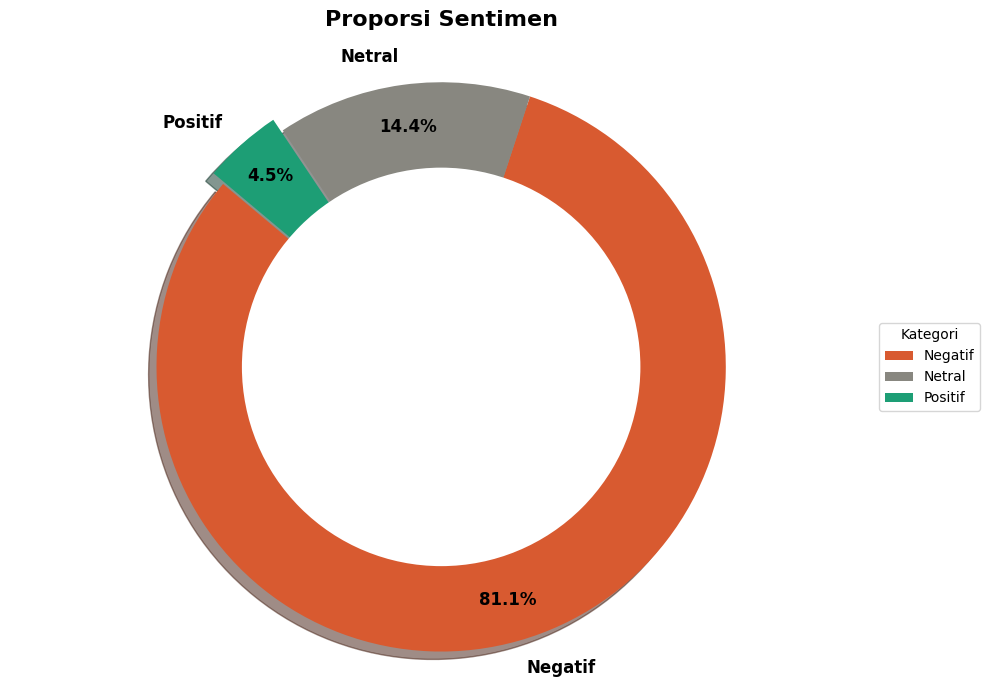

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt

# Menghitung distribusi
distribusi_manual = df_gabungan['label_manual'].value_counts()
total_manual = len(df_gabungan)
labels = distribusi_manual.index
counts = distribusi_manual.values

print("=" * 55)
print("  DISTRIBUSI LABEL — DATASET MANUAL")
print("=" * 55)
for label, jumlah in distribusi_manual.items():
    persen = jumlah / total_manual * 100
    print(f"  {label:<10} : {jumlah:>5,} ({persen:>5.1f}%)")
print(f"\n  Total data : {total_manual:,} baris")
print("=" * 55)

# Warna konsisten
warna_label = {'Negatif': '#D85A30', 'Netral': '#888780', 'Positif': '#1D9E75'}
colors = [warna_label[label] for label in labels]

# Konfigurasi 'explode' untuk menonjolkan bagian terkecil
# (0.1 berarti dipisahkan sedikit dari pusat)
explode = [0.05 if label == 'Positif' else 0 for label in labels]

plt.figure(figsize=(10, 7))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True,
    pctdistance=0.85, # Jarak persentase dari pusat
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Membuat lingkaran di tengah agar terlihat seperti donut chart (opsional, agar lebih modern)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporsi Sentimen', fontsize=16, fontweight='bold', pad=20)
plt.legend(labels, title="Kategori", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.axis('equal')
plt.tight_layout()
plt.show()

plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight')
files.download('distribusi_label.png')

In [ ]:
# Menghapus kolom yang tidak diperlukan
kolom_dihapus = ['id', 'label_inset_lexicon', 'catatan']
df_final = df_gabungan.drop(columns=[c for c in kolom_dihapus if c in df_gabungan.columns])

# Menampilkan 5 baris pertama untuk verifikasi kolom
display(df_final.head())

,text,text_clean,label_manual
0,presiden terburuk sepanjnag sejarah asli parah,presiden buruk sepanjnag sejarah asli parah,Negatif
1,banyak orang yang pintar ituu di sana tapi sem...,pintar ikut bego demi jawab,Negatif
2,siapa yg pilih wowo kemarin,pilih prabowo kemarin,Negatif
3,ulah si prabowo karena ada dendam pribadi hanc...,ulah prabowo dendam pribadi hancur indonesia b...,Negatif
4,kalau saya yakin yg maha kuasa cuma beri waktu...,yakin maha kuasa cuma beri waktu para korupsi ...,Netral


In [ ]:
df_final.to_csv('dataset_manual_labeled.csv', index=False)
print(f"\n✅ File disimpan: dataset_manual_labeled.csv ({len(df_gabungan)} baris)")

print("\n➡️  Lanjut ke tahap Label Encoding + TF-IDF")
files.download('dataset_manual_labeled.csv')


✅ File disimpan: dataset_manual_labeled.csv (10295 baris)

➡️  Lanjut ke tahap Label Encoding + TF-IDF, pakai file ini sebagai
    pengganti dataset_labeled.csv (yang lama, dari InSet Lexicon)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Label Encoding Dataset Manual


In [ ]:
!pip install scikit-learn pandas

In [ ]:
# Upload file hasil labeling dari langkah sebelumnya:
#   → dataset_labeled.csv
from google.colab import files
uploaded = files.upload()

Saving dataset_manual_labeled.csv to dataset_manual_labeled.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#LOAD DATASET HASIL LABELING
df = pd.read_csv('dataset_manual_labeled.csv')
print(f"Dataset dimuat: {len(df)} baris")
print(f"Kolom: {df.columns.tolist()}")
print(f"\nDistribusi label:")
print(df['label_manual'].value_counts())

Dataset dimuat: 10295 baris
Kolom: ['text', 'text_clean', 'label_manual']

Distribusi label:
label_manual
Negatif    8345
Netral     1487
Positif     463
Name: count, dtype: int64


In [ ]:
#Ubah dari teks menjadi angka
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label_manual'])

# Tampilkan mapping supaya jelas angka mana = label apa
print("Mapping Label Encoding:")
for i, kelas in enumerate(label_encoder.classes_):
    print(f"  {kelas:<10} → {i}")

print(f"\nContoh hasil encoding (5 baris pertama):")
print(df[['text_clean', 'label_manual', 'label_encoded']].head())

Mapping Label Encoding:
  Negatif    → 0
  Netral     → 1
  Positif    → 2

Contoh hasil encoding (5 baris pertama):
                                          text_clean label_manual  \
0        presiden buruk sepanjnag sejarah asli parah      Negatif   
1                        pintar ikut bego demi jawab      Negatif   
2                              pilih prabowo kemarin      Negatif   
3  ulah prabowo dendam pribadi hancur indonesia b...      Negatif   
4  yakin maha kuasa cuma beri waktu para korupsi ...       Netral   

   label_encoded  
0              0  
1              0  
2              0  
3              0  
4              1  


In [ ]:
#SPLIT DATA: FITUR (X) DAN TARGET (y)
X_text = df['text_clean']          # fitur: teks bersih
y      = df['label_encoded']        # target: label dalam bentuk angka

print(f"Jumlah data fitur (X) : {len(X_text)}")
print(f"Jumlah data target (y): {len(y)}")

Jumlah data fitur (X) : 10295
Jumlah data target (y): 10295


In [ ]:
#TF-IDF VECTORIZATION
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),      # Unigram + Bigram
    max_features=10000,       # batasi jumlah fitur (kata/frasa) teratas
    min_df=2,                # kata harus muncul minimal di 2 dokumen
    max_df=0.9,             # buang kata yang muncul di >90% dokumen (terlalu umum)
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(X_text)

print(f"Bentuk matriks TF-IDF : {X_tfidf.shape}")
print(f"  → {X_tfidf.shape[0]} baris (dokumen)")
print(f"  → {X_tfidf.shape[1]} kolom (fitur kata/frasa unik)")

# Lihat contoh fitur (kata/frasa) yang dihasilkan
fitur_nama = tfidf.get_feature_names_out()
print(f"\nContoh 20 fitur pertama:")
print(fitur_nama[:20])

Bentuk matriks TF-IDF : (10295, 10000)
  → 10295 baris (dokumen)
  → 10000 kolom (fitur kata/frasa unik)

Contoh 20 fitur pertama:
['abad' 'abah' 'abal' 'abal abal' 'abal pesan' 'abang' 'abang presiden'
 'abdi' 'abis' 'about' 'abu' 'acara' 'acau' 'aceh' 'aco' 'aco banget'
 'aco prabowo' 'acu' 'ada' 'ada harga']


In [ ]:
#VERIFIKASI HASIL TF-IDF
# Ambil baris pertama sebagai contoh
contoh_index = 0
print(f"Teks asli   : {df['text_clean'].iloc[contoh_index]}")
print(f"label_manual       : {df['label_manual'].iloc[contoh_index]}")

# Ambil kata/frasa dengan skor TF-IDF tertinggi di baris ini
baris_tfidf = X_tfidf[contoh_index].toarray().flatten()
top_indices = baris_tfidf.argsort()[-5:][::-1]

print(f"\nTop 5 fitur dengan skor TF-IDF tertinggi di baris ini:")
for idx in top_indices:
    if baris_tfidf[idx] > 0:
        print(f"  {fitur_nama[idx]:<20} → {baris_tfidf[idx]:.4f}")

Teks asli   : presiden buruk sepanjnag sejarah asli parah
label_manual       : Negatif

Top 5 fitur dengan skor TF-IDF tertinggi di baris ini:
  presiden buruk       → 0.5311
  buruk                → 0.4342
  asli                 → 0.4246
  sejarah              → 0.4087
  parah                → 0.3823


In [ ]:
#SIMPAN HASIL TF-IDF
#  Kita simpan 3 ini:
#  1. Matriks TF-IDF (X) dalam format .npz (sparse matrix)
#  2. Label encoded (y) dalam format .csv
#  3. Vectorizer TF-IDF
import scipy.sparse
import pickle

# Simpan matriks TF-IDF
scipy.sparse.save_npz('X_tfidf.npz', X_tfidf)
print("File disimpan: X_tfidf.npz")

# Simpan label target
y.to_csv('y_label.csv', index=False)
print("File disimpan: y_label.csv")

# Simpan vectorizer TF-IDF (supaya bisa dipakai lagi tanpa fit ulang)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("File disimpan: tfidf_vectorizer.pkl")

# Simpan label encoder juga (supaya tahu angka 0/1/2 = label apa)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("File disimpan: label_encoder.pkl")

print("\n" + "=" * 55)
print("  RINGKASAN DATASET SIAP MODELING")
print("=" * 55)
print(f"  Jumlah data         : {X_tfidf.shape[0]:,} baris")
print(f"  Jumlah fitur TF-IDF : {X_tfidf.shape[1]:,} kolom")
print(f"  Jumlah kelas target : {len(label_encoder.classes_)} kelas")
print(f"  Mapping label       : {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")
print("=" * 55)

# Download file
# files.download('X_tfidf.npz')
# files.download('y_label.csv')
# files.download('tfidf_vectorizer.pkl')
# files.download('label_encoder.pkl')



File disimpan: X_tfidf.npz
File disimpan: y_label.csv
File disimpan: tfidf_vectorizer.pkl
File disimpan: label_encoder.pkl

  RINGKASAN DATASET SIAP MODELING
  Jumlah data         : 10,295 baris
  Jumlah fitur TF-IDF : 1,769 kolom
  Jumlah kelas target : 3 kelas
  Mapping label       : {'Negatif': 0, 'Netral': 1, 'Positif': 2}


#Modeling DatasetManual


In [ ]:
!pip install scikit-learn pandas matplotlib seaborn

In [ ]:
!pip install imbalanced-learn

In [ ]:
#Upload file
#   1. X_tfidf.npz
#   2. y_label.csv
#   3. tfidf_vectorizer.pkl
#   4. label_encoder.pkl
from google.colab import files
uploaded = files.upload()

In [ ]:
#Import Library
import pickle
import numpy as np
import pandas as pd
import scipy.sparse
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
#LOAD DATA
X = scipy.sparse.load_npz('X_tfidf.npz')
y = pd.read_csv('y_label.csv').iloc[:, 0]

with open('label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# Load juga objek TF-IDF vectorizer-nya
with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

nama_kelas = label_encoder.classes_

print(f"Bentuk matriks fitur (X) : {X.shape}")
print(f"Jumlah target (y)        : {len(y)}")
print(f"Mapping kelas            : {dict(zip(range(len(nama_kelas)), nama_kelas))}")

Bentuk matriks fitur (X) : (10295, 1769)
Jumlah target (y)        : 10295
Mapping kelas            : {0: 'Negatif', 1: 'Netral', 2: 'Positif'}


In [ ]:
#TRAIN-TEST SPLIT (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Data latih (train) : {X_train.shape[0]} baris")
print(f"Data uji (test)    : {X_test.shape[0]} baris")

Data latih (train) : 8236 baris
Data uji (test)    : 2059 baris


##Modeling Sebelum Smote


### **Modeling: Logistic Regression**

---

Pada tahap ini, model **Logistic Regression** digunakan untuk melakukan klasifikasi sentimen berdasarkan fitur yang telah diproses sebelumnya.

**Parameter Penting yang Digunakan:**

* **`C=1.0`**  
  Mengatur kekuatan regularisasi.  
  Nilai default `1.0` digunakan karena cukup seimbang antara mencegah *overfitting* dan menjaga performa model.

* **`solver='liblinear'`**  
  Solver ini cocok digunakan untuk dataset dengan fitur berdimensi tinggi, seperti hasil representasi teks menggunakan TF-IDF.

* **`class_weight='balanced'`**  
  Digunakan untuk menangani data yang tidak seimbang antar kelas.  
  Parameter ini membantu model agar tidak terlalu bias terhadap kelas mayoritas.

* **`max_iter=1000`**  
  Menentukan jumlah iterasi maksimum agar proses pelatihan model memiliki cukup waktu untuk mencapai konvergensi.

**Kesimpulan:**  
Pengaturan parameter ini bertujuan untuk menghasilkan model Logistic Regression yang stabil, mampu menangani data teks berdimensi tinggi, dan lebih adil terhadap distribusi kelas yang tidak seimbang.

In [ ]:
model_lr_sbl = LogisticRegression(
    C=1.0, solver='liblinear',
    class_weight='balanced',
    max_iter=1000, random_state=42
)
model_lr_sbl.fit(X_train, y_train)
y_pred_lr_sbl = model_lr_sbl.predict(X_test)

print("Logistic Regression selesai dilatih")

Logistic Regression selesai dilatih


### **Modeling: Support Vector Machine (Linear SVM)**

---

Pada tahap ini, model **Support Vector Machine (SVM)** dengan kernel linear digunakan untuk melakukan klasifikasi sentimen berdasarkan fitur teks yang telah diproses.

**Parameter Penting yang Digunakan:**

* **`kernel='linear'`**  
  Menggunakan kernel linear yang cocok untuk data teks berdimensi tinggi, seperti fitur hasil TF-IDF.

* **`C=1.0`**  
  Mengatur kekuatan regularisasi.  
  Nilai `1.0` digunakan sebagai pengaturan default yang seimbang antara menjaga margin dan mengurangi kesalahan klasifikasi.

* **`class_weight='balanced'`**  
  Digunakan untuk menangani data yang tidak seimbang antar kelas.  
  Parameter ini membantu model memberi perhatian lebih pada kelas minoritas.

**Kesimpulan:**  
Model **Linear SVM** dipilih karena efektif untuk klasifikasi teks, terutama ketika data memiliki jumlah fitur yang besar dan distribusi kelas yang tidak seimbang.

In [ ]:
model_svm_sbl = SVC(
    kernel='linear', C=1.0,
    class_weight='balanced',
    random_state=42
)
model_svm_sbl.fit(X_train, y_train)
y_pred_svm_sbl = model_svm_sbl.predict(X_test)

print("SVM selesai dilatih")

SVM selesai dilatih


### **Modeling: Naive Bayes (MultinomialNB)**

---

Pada tahap ini, model **Multinomial Naive Bayes** digunakan untuk melakukan klasifikasi sentimen berdasarkan fitur teks yang telah direpresentasikan dalam bentuk numerik, seperti TF-IDF.

**Parameter Penting yang Digunakan:**

* **`alpha=1.0`**  
  Digunakan sebagai nilai *Laplace smoothing*.  
  Parameter ini berfungsi untuk mencegah probabilitas bernilai `0` pada kata yang tidak muncul di data latih.

**Catatan Penting:**

Model **MultinomialNB** tidak memiliki parameter **`class_weight`**, sehingga data yang tidak seimbang (*imbalanced data*) tidak dikompensasi secara otomatis.

Hal ini dapat disebutkan sebagai salah satu keterbatasan model ketika membandingkan performa **Logistic Regression**, **Linear SVM**, dan **Multinomial Naive Bayes** dalam skripsi.

**Kesimpulan:**  
Multinomial Naive Bayes dipilih karena sederhana, cepat, dan umum digunakan untuk klasifikasi teks. Namun, model ini memiliki keterbatasan dalam menangani distribusi kelas yang tidak seimbang secara otomatis.

In [ ]:
model_nb_sbl = MultinomialNB(alpha=1.0)
model_nb_sbl.fit(X_train, y_train)
y_pred_nb_sbl = model_nb_sbl.predict(X_test)

print("Naive Bayes selesai dilatih")

Naive Bayes selesai dilatih


##Modeling Sesudah SMOTE

###Menerapkan Smote

In [ ]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

###Logistik Regression



In [ ]:
model_lr_smt = LogisticRegression(
    C=1.0, solver='liblinear',
    class_weight='balanced',
    max_iter=1000, random_state=42

)
model_lr_smt.fit(X_train_smote, y_train_smote)
y_pred_lr_smt = model_lr_smt.predict(X_test)

print("Training Logistik Regression SESUDAH SMOTE selesai")

Training Logistik Regression SESUDAH SMOTE selesai


###SVM

In [ ]:
model_svm_smt = SVC(
    kernel='linear', C=1.0,
    class_weight='balanced',
    random_state=42

)
model_svm_smt.fit(X_train_smote, y_train_smote)
y_pred_svm_smt = model_svm_smt.predict(X_test)

print("Training SVM SESUDAH SMOTE selesai")

Training SVM SESUDAH SMOTE selesai


###Naive Bayes


In [ ]:
model_nb_smt = MultinomialNB(alpha=1.0)
model_nb_smt.fit(X_train_smote, y_train_smote)
y_pred_nb_smt = model_nb_smt.predict(X_test)

print("Training Naive Bayes SESUDAH SMOTE selesai")

Training Naive Bayes SESUDAH SMOTE selesai


##WorldCloud


In [ ]:
!pip install wordcloud matplotlib

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [ ]:
nama_fitur = tfidf.get_feature_names_out()
nama_kelas = label_encoder.classes_

print(f"Jumlah fitur (kata/frasa) : {len(nama_fitur)}")
print(f"Kelas                     : {dict(zip(range(len(nama_kelas)), nama_kelas))}")

Jumlah fitur (kata/frasa) : 10000
Kelas                     : {0: 'Negatif', 1: 'Netral', 2: 'Positif'}


In [ ]:
def ambil_bobot_kata(model, index_kelas, nama_model):
    """
    Ambil array bobot kata untuk satu kelas tertentu dari model.

    index_kelas: indeks kelas (0, 1, atau 2) sesuai urutan nama_kelas
    nama_model : 'lr', 'svm', atau 'nb' — menentukan atribut yang dibaca

    Return: array numpy 1D, satu nilai per fitur/kata di vocabulary TF-IDF
    """
    if nama_model in ('lr', 'svm'):
        # coef_ bentuknya (jumlah_kelas, jumlah_fitur) untuk kasus normal.
        # Tapi untuk SVC multi-class, bentuknya bisa berbeda (one-vs-one),
        # dan elemennya bisa berupa sparse matrix, bukan array biasa.
        # np.asarray + .ravel() memastikan hasilnya selalu array 1D bersih.
        bobot = model.coef_[index_kelas]

        # Jika hasilnya masih berupa sparse matrix (punya method .toarray())
        if hasattr(bobot, 'toarray'):
            bobot = bobot.toarray()

        bobot = np.asarray(bobot).ravel()
        return bobot

    elif nama_model == 'nb':
        bobot = np.asarray(model.feature_log_prob_[index_kelas]).ravel()
        return bobot
    else:
        raise ValueError(f"nama_model tidak dikenal: {nama_model}")


def buat_wordcloud_dari_bobot(bobot, nama_fitur, judul, ax):
    """
    Buat wordcloud dari array bobot kata, hanya pakai bobot POSITIF
    (kata yang benar-benar MENDORONG ke kelas ini, bukan menjauhinya).
    """
    # Pastikan bobot adalah array numpy 1D bersih (jaga-jaga kalau
    # ambil_bobot_kata dipanggil langsung tanpa lewat fungsi pembersih)
    bobot = np.asarray(bobot).ravel()

    if len(bobot) != len(nama_fitur):
        raise ValueError(
            f"Panjang bobot ({len(bobot)}) tidak sama dengan "
            f"jumlah nama_fitur ({len(nama_fitur)}) — cek bentuk coef_ model"
        )

    # Pasangkan setiap kata dengan bobotnya
    pasangan_kata_bobot = dict(zip(nama_fitur, bobot.tolist()))

    # Hanya ambil kata dengan bobot positif (kata yang mendorong KE kelas ini)
    # Kata dengan bobot negatif artinya "menjauhkan" dari kelas ini —
    # tidak relevan untuk wordcloud kelas tersebut
    kata_positif = {
        k: v for k, v in pasangan_kata_bobot.items()
        if v > 0
        and len(k) >= 3
        and not any(c.isdigit() for c in k)
    }

    if len(kata_positif) == 0:
        ax.text(0.5, 0.5, 'Tidak ada kata dengan bobot positif',
                ha='center', va='center')
        ax.set_title(judul)
        ax.axis('off')
        return

    wc = WordCloud(
        width=500, height=350,
        background_color='white',
        colormap='viridis',
        max_words=50
    ).generate_from_frequencies(kata_positif)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(judul, fontsize=13, fontweight='bold')
    ax.axis('off')

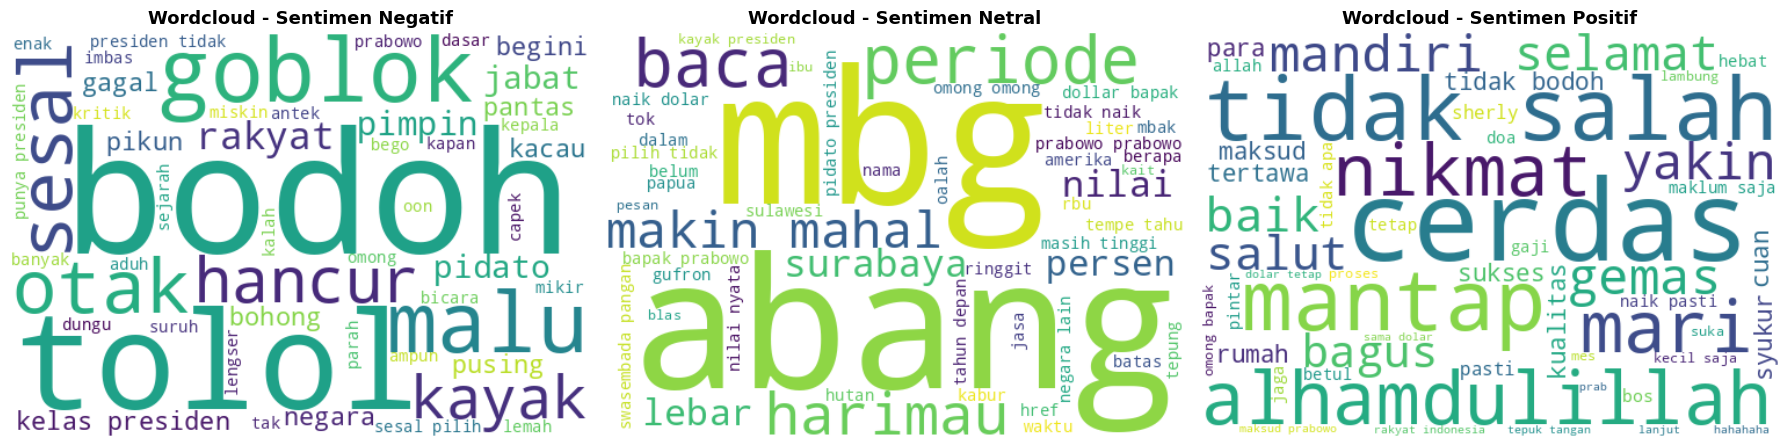

In [ ]:
#Logistik Regregsion
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, kelas in enumerate(nama_kelas):
    bobot = ambil_bobot_kata(model_lr_sbl, i, 'lr')
    buat_wordcloud_dari_bobot(bobot, nama_fitur, f'Wordcloud - Sentimen {kelas}', axes[i])

plt.tight_layout()
plt.savefig('wordcloud_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

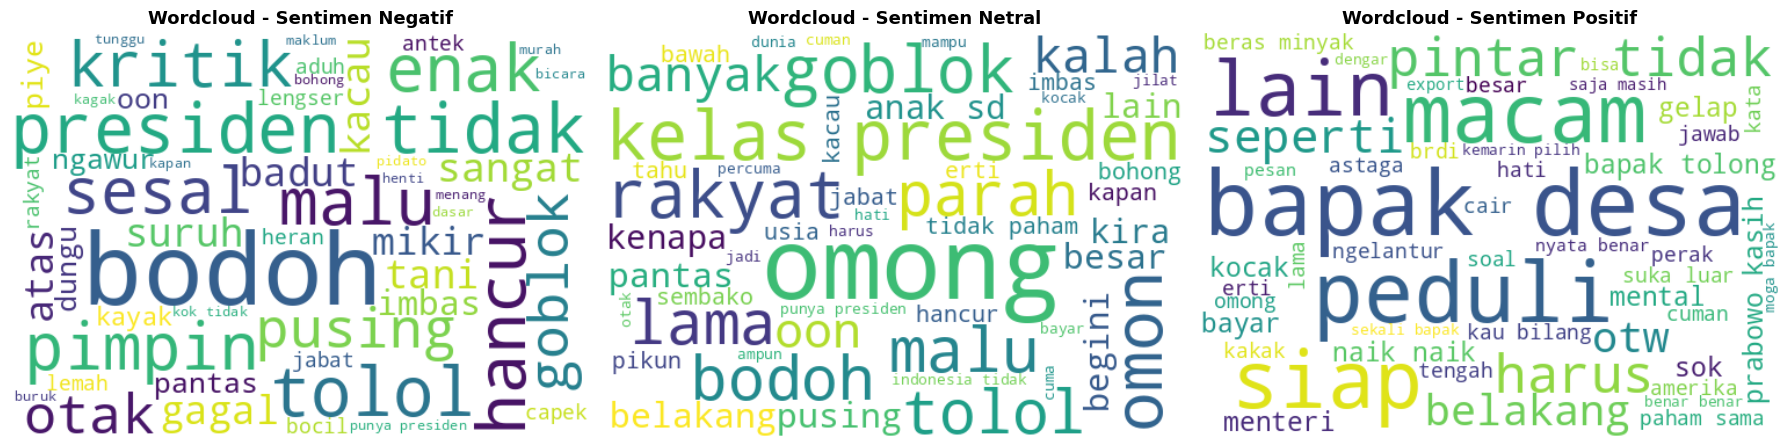

In [ ]:
#svm
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, kelas in enumerate(nama_kelas):
    bobot = ambil_bobot_kata(model_svm_sbl, i, 'svm')
    buat_wordcloud_dari_bobot(bobot, nama_fitur, f'Wordcloud - Sentimen {kelas}', axes[i])

plt.tight_layout()
plt.savefig('wordcloud_svm.png', dpi=150, bbox_inches='tight')
plt.show()

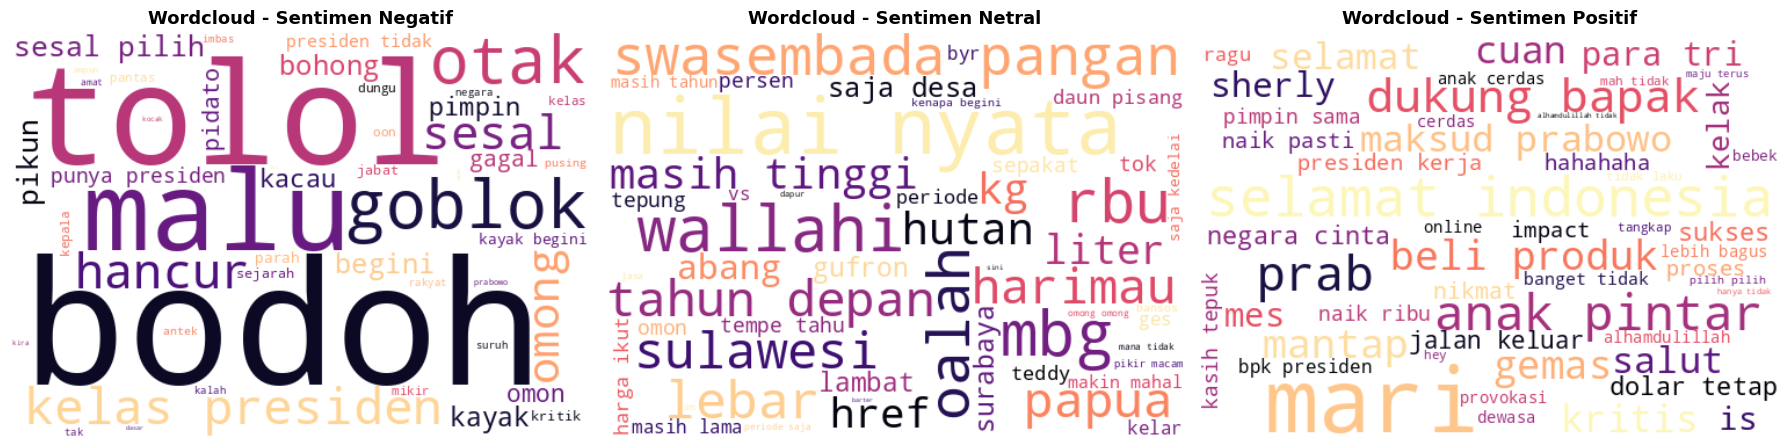

In [ ]:
#naive bayes
def buat_wordcloud_naive_bayes(model, index_kelas, nama_fitur, judul, ax, top_n=50):
    """
    Versi khusus untuk Naive Bayes.

    PENTING: tidak memakai log-probability mentah, karena kata yang
    sering muncul di SELURUH dataset (misal "tidak", "presiden", "dolar"
    — yang memang sentral di topik penelitian ini) akan selalu punya
    log-probability tertinggi di SEMUA kelas, bukan cuma kelas tertentu.

    Sebagai gantinya dipakai LOG-LIKELIHOOD RATIO:
        skor = log_prob[kelas_ini] - rata-rata(log_prob[kelas_lain])

    Ini mengukur seberapa kata tersebut LEBIH menonjol di kelas ini
    dibanding kelas lain — bukan seberapa sering dia muncul secara umum.
    """
    log_prob = model.feature_log_prob_  # bentuk: (jumlah_kelas, jumlah_fitur)
    jumlah_kelas = log_prob.shape[0]

    skor_kelas_ini = np.asarray(log_prob[index_kelas]).ravel()

    # Rata-rata log_prob dari SEMUA kelas LAIN (bukan kelas ini)
    index_kelas_lain = [i for i in range(jumlah_kelas) if i != index_kelas]
    skor_kelas_lain = np.asarray(log_prob[index_kelas_lain]).mean(axis=0).ravel()

    # Log-likelihood ratio: makin tinggi, makin spesifik ke kelas ini
    rasio = skor_kelas_ini - skor_kelas_lain

    pasangan_kata_rasio = dict(zip(nama_fitur, rasio.tolist()))

    # Ambil top_n kata dengan rasio tertinggi (paling membedakan kelas ini)
    top_kata = dict(sorted(pasangan_kata_rasio.items(),
                            key=lambda x: x[1], reverse=True)[:top_n])

    # Geser supaya semua nilai positif (wordcloud butuh angka > 0)
    nilai_minimum = min(top_kata.values())
    top_kata_positif = {k: (v - nilai_minimum + 0.01) for k, v in top_kata.items()}

    wc = WordCloud(
        width=500, height=350,
        background_color='white',
        colormap='magma',
        max_words=50
    ).generate_from_frequencies(top_kata_positif)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(judul, fontsize=13, fontweight='bold')
    ax.axis('off')


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, kelas in enumerate(nama_kelas):
    buat_wordcloud_naive_bayes(model_nb_sbl, i, nama_fitur, f'Wordcloud - Sentimen {kelas}', axes[i])

plt.tight_layout()
plt.savefig('wordcloud_naive_bayes.png', dpi=150, bbox_inches='tight')
plt.show()

###10 kata paling berpengaruh

In [ ]:
#tabel top 10 kata
import pandas as pd

def top_kata_tabel(model, nama_model, top_n=10):
    """Buat tabel top_n kata per kelas untuk satu model."""
    hasil = []

    if nama_model == 'nb':
        # Pakai log-likelihood ratio, BUKAN log-probability mentah —
        # supaya kata yang ditampilkan benar-benar membedakan antar
        # kelas, bukan cuma kata yang sering muncul di semua kelas
        log_prob = model.feature_log_prob_
        jumlah_kelas = log_prob.shape[0]

        for i, kelas in enumerate(nama_kelas):
            index_kelas_lain = [j for j in range(jumlah_kelas) if j != i]
            skor_kelas_ini = np.asarray(log_prob[i]).ravel()
            skor_kelas_lain = np.asarray(log_prob[index_kelas_lain]).mean(axis=0).ravel()
            rasio = skor_kelas_ini - skor_kelas_lain

            top_indices = rasio.argsort()[-top_n:][::-1]
            for idx in top_indices:
                hasil.append({
                    'kelas': kelas,
                    'kata': nama_fitur[idx],
                    'bobot': round(float(rasio[idx]), 4)
                })
    else:
        for i, kelas in enumerate(nama_kelas):
            bobot = ambil_bobot_kata(model, i, nama_model)
            top_indices = bobot.argsort()[-top_n:][::-1]
            for idx in top_indices:
                hasil.append({
                    'kelas': kelas,
                    'kata': nama_fitur[idx],
                    'bobot': round(float(bobot[idx]), 4)
                })

    return pd.DataFrame(hasil)

print("=" * 60)
print("TOP 10 KATA — LOGISTIC REGRESSION")
print("=" * 60)
tabel_lr = top_kata_tabel(model_lr, 'lr')
print(tabel_lr.to_string(index=False))

print("\n" + "=" * 60)
print("TOP 10 KATA — SVM")
print("=" * 60)
tabel_svm = top_kata_tabel(model_svm, 'svm')
print(tabel_svm.to_string(index=False))

print("\n" + "=" * 60)
print("TOP 10 KATA — NAIVE BAYES")
print("=" * 60)
tabel_nb = top_kata_tabel(model_nb, 'nb')
print(tabel_nb.to_string(index=False))

TOP 10 KATA — LOGISTIC REGRESSION
  kelas          kata  bobot
Negatif         bodoh 3.7459
Negatif         tolol 2.2443
Negatif          otak 2.0435
Negatif          malu 2.0303
Negatif        goblok 1.9804
Negatif         sesal 1.8621
Negatif        hancur 1.8050
Negatif        rakyat 1.7775
Negatif         kayak 1.7246
Negatif        pimpin 1.7195
 Netral           mbg 1.8408
 Netral         abang 1.8282
 Netral       harimau 1.7953
 Netral       periode 1.7859
 Netral          baca 1.7493
 Netral bapak prabowo 1.6471
 Netral   makin mahal 1.6459
 Netral         lebar 1.6160
 Netral      surabaya 1.6036
 Netral         liter 1.5743
Positif        cerdas 4.2968
Positif        mantap 3.9749
Positif alhamdulillah 3.7120
Positif          mari 3.7077
Positif        nikmat 3.7043
Positif         gemas 3.5235
Positif       mandiri 3.5063
Positif         yakin 3.2036
Positif    salah desa 3.1557
Positif         salut 3.1461

TOP 10 KATA — SVM
  kelas           kata  bobot
Negatif          b

#Evaluasi Manual

## **Fungsi Evaluasi Model**

---

Pada tahap ini, dibuat fungsi evaluasi untuk menghitung performa setiap model klasifikasi.

**Metrik Evaluasi yang Digunakan:**

* **Accuracy**  
  Mengukur persentase prediksi yang benar dari seluruh data uji.

* **Precision**  
  Mengukur ketepatan model dalam memprediksi suatu kelas.

* **Recall**  
  Mengukur kemampuan model dalam menemukan seluruh data yang benar pada suatu kelas.

* **F1-Score**  
  Menggabungkan nilai precision dan recall dalam satu metrik.

**Catatan:**  
Karena dataset memiliki **3 kelas sentimen**, evaluasi menggunakan **macro average** agar setiap kelas memiliki bobot yang sama dalam perhitungan metrik.

**Tujuan Fungsi:**  
Fungsi ini digunakan untuk mengevaluasi satu model, kemudian menampilkan hasil metrik dan laporan klasifikasi secara lengkap.

In [ ]:
def evaluasi_model(nama_model, y_test, y_pred, nama_kelas):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print(f"\n{'=' * 60}")
    print(f"  EVALUASI: {nama_model}")
    print(f"{'=' * 60}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (macro average)")
    print(f"  Recall    : {rec:.4f}  (macro average)")
    print(f"  F1-Score  : {f1:.4f}  (macro average)")
    print(f"\n  Classification Report Lengkap:")
    print(classification_report(
        y_test, y_pred,
        target_names=nama_kelas,
        zero_division=0
    ))
    return {'model': nama_model, 'accuracy': acc,
            'precision': prec, 'recall': rec, 'f1_score': f1}


def tampilkan_confusion_matrix(nama_model, y_test, y_pred, nama_kelas, ax):
    """Tampilkan confusion matrix ke subplot ax yang diberikan."""
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=nama_kelas, yticklabels=nama_kelas,
        ax=ax
    )
    ax.set_title(nama_model, fontsize=11, fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')


def cv_semua_metrik(model, X, y, nama_model, k=5):
    """Jalankan cross validation untuk 4 metrik sekaligus."""
    daftar_scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision_macro',
        'recall': 'recall_macro',
        'f1_score': 'f1_macro',
    }
    hasil = {'model': nama_model}
    print(f"\n{nama_model}:")
    for nama, scoring in daftar_scoring.items():
        skor = cross_val_score(model, X, y, cv=k, scoring=scoring)
        hasil[f'cv_{nama}_mean'] = skor.mean()
        hasil[f'cv_{nama}_std']  = skor.std()
        print(f"  {nama:<10}: {skor.mean():.4f} (+/- {skor.std():.4f})")
    return hasil

##Evaluasi Sebelum Smote

###Cek Distribusi Data Sebelum Smote


In [ ]:
print("=" * 60)
print("  DISTRIBUSI DATA TRAINING SEBELUM SMOTE")
print("=" * 60)
distribusi_sebelum = pd.Series(y_train).value_counts()
total_sebelum = len(y_train)
for label, jumlah in distribusi_sebelum.items():
    persen = jumlah / total_sebelum * 100
    print(f"  {nama_kelas[label]:<10} : {jumlah:>5,} ({persen:>5.1f}%)")
print(f"\n  Total data training: {total_sebelum:,}")

  DISTRIBUSI DATA TRAINING SEBELUM SMOTE
  Negatif    : 6,676 ( 81.1%)
  Netral     : 1,190 ( 14.4%)
  Positif    :   370 (  4.5%)

  Total data training: 8,236


###Evaluasi: Logistic Regression

In [ ]:
hasil_lr_sbl  = evaluasi_model('Logistic Regression (Sebelum SMOTE)', y_test, y_pred_lr_sbl, nama_kelas)


  EVALUASI: Logistic Regression (Sebelum SMOTE)
  Accuracy  : 0.7960
  Precision : 0.4867  (macro average)
  Recall    : 0.3993  (macro average)
  F1-Score  : 0.4100  (macro average)

  Classification Report Lengkap:
              precision    recall  f1-score   support

     Negatif       0.83      0.95      0.89      1669
      Netral       0.40      0.11      0.18       297
     Positif       0.23      0.13      0.16        93

    accuracy                           0.80      2059
   macro avg       0.49      0.40      0.41      2059
weighted avg       0.74      0.80      0.75      2059



###Evaluasi: SVM

In [ ]:
hasil_svm_sbl = evaluasi_model('SVM (Sebelum SMOTE)', y_test, y_pred_svm_sbl, nama_kelas)


  EVALUASI: SVM (Sebelum SMOTE)
  Accuracy  : 0.6625
  Precision : 0.4240  (macro average)
  Recall    : 0.4640  (macro average)
  F1-Score  : 0.4301  (macro average)

  Classification Report Lengkap:
              precision    recall  f1-score   support

     Negatif       0.87      0.72      0.79      1669
      Netral       0.25      0.46      0.33       297
     Positif       0.15      0.20      0.17        93

    accuracy                           0.66      2059
   macro avg       0.42      0.46      0.43      2059
weighted avg       0.75      0.66      0.70      2059



###Evaluasi: Naive Bayes

In [ ]:
hasil_nb_sbl  = evaluasi_model('Naive Bayes (Sebelum SMOTE)', y_test, y_pred_nb_sbl, nama_kelas)


  EVALUASI: Naive Bayes (Sebelum SMOTE)
  Accuracy  : 0.8091
  Precision : 0.2701  (macro average)
  Recall    : 0.3327  (macro average)
  F1-Score  : 0.2982  (macro average)

  Classification Report Lengkap:
              precision    recall  f1-score   support

     Negatif       0.81      1.00      0.89      1669
      Netral       0.00      0.00      0.00       297
     Positif       0.00      0.00      0.00        93

    accuracy                           0.81      2059
   macro avg       0.27      0.33      0.30      2059
weighted avg       0.66      0.81      0.73      2059



###Confusion Matrix Sebelum SMOTE

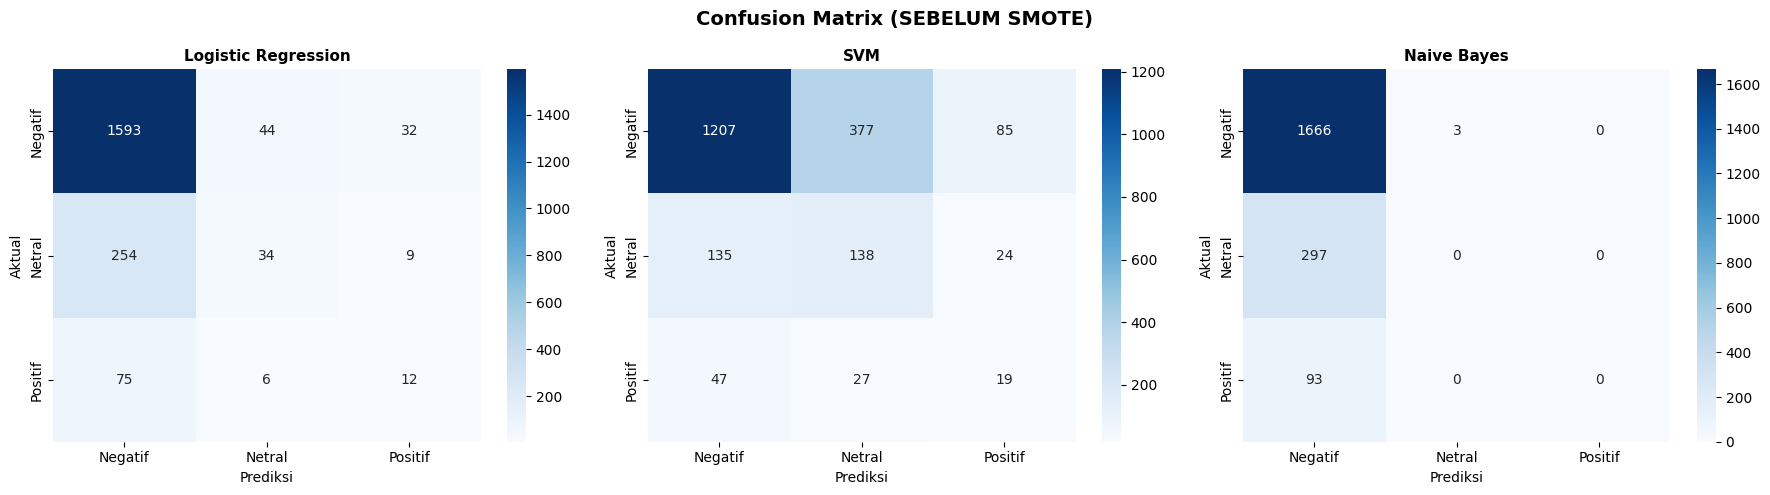

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix (SEBELUM SMOTE)', fontsize=14, fontweight='bold')

tampilkan_confusion_matrix('Logistic Regression', y_test, y_pred_lr_sbl,  nama_kelas, axes[0])
tampilkan_confusion_matrix('SVM',                  y_test, y_pred_svm_sbl, nama_kelas, axes[1])
tampilkan_confusion_matrix('Naive Bayes',           y_test, y_pred_nb_sbl,  nama_kelas, axes[2])

plt.tight_layout()
plt.savefig('confusion_matrix_sebelum_smote.png', dpi=150, bbox_inches='tight')
plt.show()

###5-FOLD CROSS VALIDATION Sebelum SMOTE

In [ ]:
print("\n" + "=" * 60)
print("  5-FOLD CROSS VALIDATION — SEBELUM SMOTE")
print("=" * 60)

hasil_cv_lr_sbl  = cv_semua_metrik(model_lr_sbl,  X, y, 'Logistic Regression (Sebelum SMOTE)')
hasil_cv_svm_sbl = cv_semua_metrik(model_svm_sbl, X, y, 'SVM (Sebelum SMOTE)')
hasil_cv_nb_sbl  = cv_semua_metrik(model_nb_sbl,  X, y, 'Naive Bayes (Sebelum SMOTE)')


  5-FOLD CROSS VALIDATION — SEBELUM SMOTE

Logistic Regression (Sebelum SMOTE):
  accuracy  : 0.7937 (+/- 0.0072)
  precision : 0.4669 (+/- 0.0248)
  recall    : 0.3836 (+/- 0.0093)
  f1_score  : 0.3911 (+/- 0.0132)

SVM (Sebelum SMOTE):
  accuracy  : 0.6556 (+/- 0.0363)
  precision : 0.4242 (+/- 0.0120)
  recall    : 0.4584 (+/- 0.0133)
  f1_score  : 0.4263 (+/- 0.0189)

Naive Bayes (Sebelum SMOTE):
  accuracy  : 0.8102 (+/- 0.0004)
  precision : 0.2702 (+/- 0.0000)
  recall    : 0.3332 (+/- 0.0001)
  f1_score  : 0.2984 (+/- 0.0001)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

##Evaluasi Sesudah Smote

###Cek Distribusi Data Sesudah Smote

In [ ]:
print("=" * 60)
print("  DISTRIBUSI DATA TRAINING SESUDAH SMOTE")
print("=" * 60)
distribusi_sesudah = pd.Series(y_train_smote).value_counts()
total_sesudah = len(y_train_smote)
for label, jumlah in distribusi_sesudah.items():
    persen = jumlah / total_sesudah * 100
    print(f"  {nama_kelas[label]:<10} : {jumlah:>5,} ({persen:>5.1f}%)")
print(f"\n  Total data training setelah SMOTE: {total_sesudah:,}")
print(f"  Penambahan data sintetis          : {total_sesudah - total_sebelum:,} baris")

  DISTRIBUSI DATA TRAINING SESUDAH SMOTE
  Negatif    : 6,676 ( 33.3%)
  Netral     : 6,676 ( 33.3%)
  Positif    : 6,676 ( 33.3%)

  Total data training setelah SMOTE: 20,028
  Penambahan data sintetis          : 11,792 baris


###Logistik Regression


In [ ]:
hasil_lr_smt  = evaluasi_model('Logistic Regression (Sesudah SMOTE)', y_test, y_pred_lr_smt, nama_kelas)


  EVALUASI: Logistic Regression (Sesudah SMOTE)
  Accuracy  : 0.6780
  Precision : 0.4384  (macro average)
  Recall    : 0.4951  (macro average)
  F1-Score  : 0.4513  (macro average)

  Classification Report Lengkap:
              precision    recall  f1-score   support

     Negatif       0.88      0.74      0.80      1669
      Netral       0.27      0.43      0.33       297
     Positif       0.17      0.31      0.22        93

    accuracy                           0.68      2059
   macro avg       0.44      0.50      0.45      2059
weighted avg       0.76      0.68      0.71      2059



### SVM

In [ ]:
hasil_svm_smt = evaluasi_model('SVM (Sesudah SMOTE)', y_test, y_pred_svm_smt, nama_kelas)


  EVALUASI: SVM (Sesudah SMOTE)
  Accuracy  : 0.7033
  Precision : 0.4313  (macro average)
  Recall    : 0.4571  (macro average)
  F1-Score  : 0.4387  (macro average)

  Classification Report Lengkap:
              precision    recall  f1-score   support

     Negatif       0.86      0.78      0.82      1669
      Netral       0.29      0.43      0.34       297
     Positif       0.14      0.16      0.15        93

    accuracy                           0.70      2059
   macro avg       0.43      0.46      0.44      2059
weighted avg       0.75      0.70      0.72      2059



###Naive Bayes

In [ ]:
hasil_nb_smt  = evaluasi_model('Naive Bayes (Sesudah SMOTE)', y_test, y_pred_nb_smt, nama_kelas)


  EVALUASI: Naive Bayes (Sesudah SMOTE)
  Accuracy  : 0.6416
  Precision : 0.4156  (macro average)
  Recall    : 0.4862  (macro average)
  F1-Score  : 0.4201  (macro average)

  Classification Report Lengkap:
              precision    recall  f1-score   support

     Negatif       0.88      0.71      0.79      1669
      Netral       0.24      0.33      0.28       297
     Positif       0.13      0.42      0.20        93

    accuracy                           0.64      2059
   macro avg       0.42      0.49      0.42      2059
weighted avg       0.75      0.64      0.69      2059



###Confusion Matrix Sesudah SMOTE

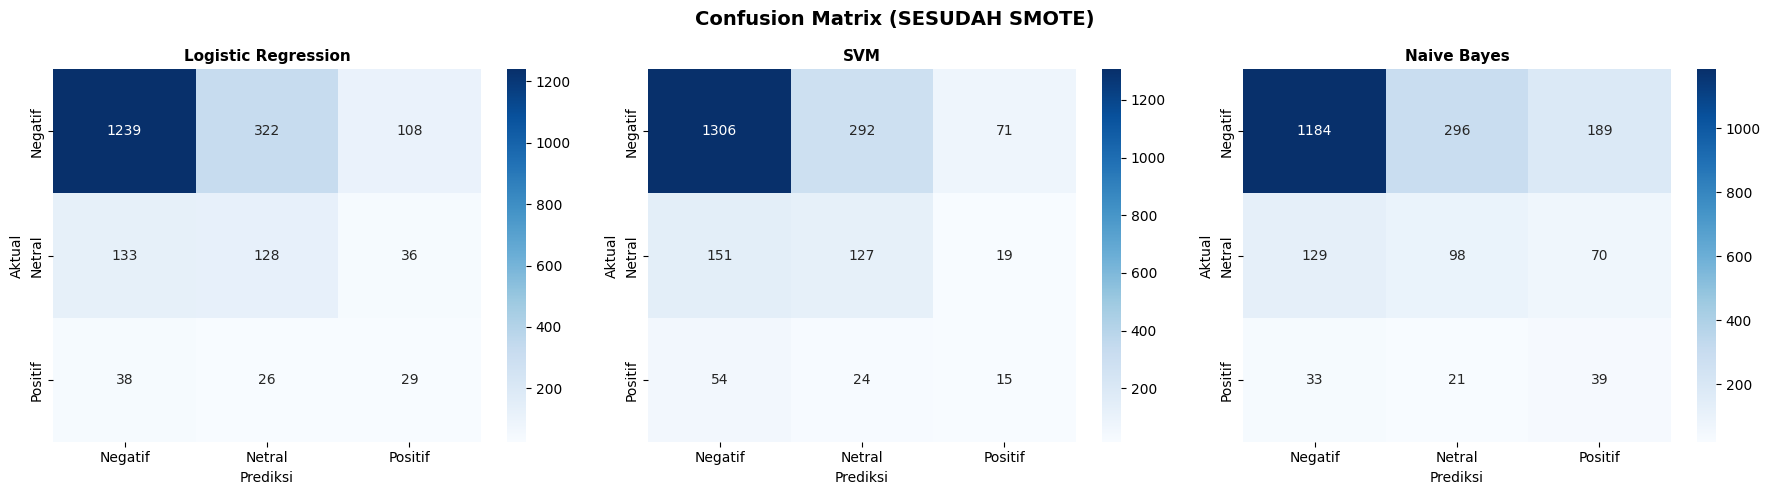

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix (SESUDAH SMOTE)', fontsize=14, fontweight='bold')

tampilkan_confusion_matrix('Logistic Regression', y_test, y_pred_lr_smt,  nama_kelas, axes[0])
tampilkan_confusion_matrix('SVM',                  y_test, y_pred_svm_smt, nama_kelas, axes[1])
tampilkan_confusion_matrix('Naive Bayes',           y_test, y_pred_nb_smt,  nama_kelas, axes[2])

plt.tight_layout()
plt.savefig('confusion_matrix_sesudah_smote.png', dpi=150, bbox_inches='tight')
plt.show()

###5-FOLD CROSS VALIDATION Sesudah SMOTE

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline

def buat_pipeline_smote(model):
    """Bungkus model dengan SMOTE dalam Pipeline yang aman untuk CV."""
    return ImbPipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=5)),
        ('model', model)
    ])

pipeline_lr_smt  = buat_pipeline_smote(LogisticRegression(C=1.0, solver='liblinear', max_iter=1000, random_state=42))
pipeline_svm_smt = buat_pipeline_smote(SVC(kernel='linear', C=1.0, random_state=42))
pipeline_nb_smt  = buat_pipeline_smote(MultinomialNB(alpha=1.0))

print("\n" + "=" * 60)
print("  5-FOLD CROSS VALIDATION (SESUDAH SMOTE)")
print("=" * 60)

hasil_cv_lr_smt  = cv_semua_metrik(pipeline_lr_smt,  X, y, 'Logistic Regression (Sesudah SMOTE)')
hasil_cv_svm_smt = cv_semua_metrik(pipeline_svm_smt, X, y, 'SVM (Sesudah SMOTE)')
hasil_cv_nb_smt  = cv_semua_metrik(pipeline_nb_smt,  X, y, 'Naive Bayes (Sesudah SMOTE)')


  5-FOLD CROSS VALIDATION (SESUDAH SMOTE)

Logistic Regression (Sesudah SMOTE):
  accuracy  : 0.6712 (+/- 0.0292)
  precision : 0.4381 (+/- 0.0166)
  recall    : 0.4890 (+/- 0.0196)
  f1_score  : 0.4477 (+/- 0.0225)

SVM (Sesudah SMOTE):
  accuracy  : 0.6992 (+/- 0.0237)
  precision : 0.4326 (+/- 0.0152)
  recall    : 0.4488 (+/- 0.0127)
  f1_score  : 0.4339 (+/- 0.0152)

Naive Bayes (Sesudah SMOTE):
  accuracy  : 0.6280 (+/- 0.0390)
  precision : 0.4112 (+/- 0.0190)
  recall    : 0.4734 (+/- 0.0335)
  f1_score  : 0.4152 (+/- 0.0278)


##TABEL EVALUASI: SEBELUM vs SESUDAH SMOTE

In [ ]:
tabel_eval = pd.DataFrame([
    hasil_lr_sbl,  hasil_lr_smt,
    hasil_svm_sbl, hasil_svm_smt,
    hasil_nb_sbl,  hasil_nb_smt,
])
tabel_eval = tabel_eval.sort_values('f1_score', ascending=False).reset_index(drop=True)

print("\n" + "=" * 70)
print("  TABEL PERBANDINGAN EVALUASI — SEBELUM vs SESUDAH SMOTE")
print("  (diurutkan berdasarkan F1-Score)")
print("=" * 70)
print(tabel_eval.to_string(index=False))
print("=" * 70)


  TABEL PERBANDINGAN EVALUASI — SEBELUM vs SESUDAH SMOTE
  (diurutkan berdasarkan F1-Score)
                              model  accuracy  precision   recall  f1_score
Logistic Regression (Sesudah SMOTE)  0.677999   0.438420 0.495055  0.451343
                SVM (Sesudah SMOTE)  0.703254   0.431289 0.457135  0.438714
                SVM (Sebelum SMOTE)  0.662458   0.424007 0.464045  0.430105
        Naive Bayes (Sesudah SMOTE)  0.641574   0.415553 0.486243  0.420059
Logistic Regression (Sebelum SMOTE)  0.796017   0.486667 0.399325  0.410026
        Naive Bayes (Sebelum SMOTE)  0.809131   0.270104 0.332734  0.298166


##TABEL Cross Validation: SEBELUM vs SESUDAH SMOTE

In [ ]:
tabel_cv = pd.DataFrame([
    hasil_cv_lr_sbl,  hasil_cv_lr_smt,
    hasil_cv_svm_sbl, hasil_cv_svm_smt,
    hasil_cv_nb_sbl,  hasil_cv_nb_smt,
])
tabel_cv = tabel_cv.sort_values('cv_f1_score_mean', ascending=False).reset_index(drop=True)

print("\n" + "=" * 70)
print("  TABEL 5-FOLD CV — SEBELUM vs SESUDAH SMOTE")
print("  (diurutkan berdasarkan CV F1-Score)")
print("=" * 70)
print(tabel_cv.to_string(index=False))
print("=" * 70)


  TABEL 5-FOLD CV — SEBELUM vs SESUDAH SMOTE
  (diurutkan berdasarkan CV F1-Score)
                              model  cv_accuracy_mean  cv_accuracy_std  cv_precision_mean  cv_precision_std  cv_recall_mean  cv_recall_std  cv_f1_score_mean  cv_f1_score_std
Logistic Regression (Sesudah SMOTE)          0.671200         0.029161           0.438117          0.016590        0.489014       0.019616          0.447745         0.022469
                SVM (Sesudah SMOTE)          0.699174         0.023665           0.432593          0.015238        0.448842       0.012689          0.433935         0.015152
                SVM (Sebelum SMOTE)          0.655561         0.036336           0.424179          0.011963        0.458392       0.013326          0.426336         0.018941
        Naive Bayes (Sesudah SMOTE)          0.627975         0.038971           0.411198          0.018952        0.473411       0.033516          0.415164         0.027768
Logistic Regression (Sebelum SMOTE)          0

In [ ]:
#Simpan Hasil
tabel_eval.to_csv('tabel_perbandingan_smote_evaluasi.csv', index=False)
tabel_cv.to_csv('tabel_perbandingan_smote_cv.csv', index=False)

print("\nFile disimpan:")
print("   tabel_perbandingan_smote_evaluasi.csv")
print("   tabel_perbandingan_smote_cv.csv")

from google.colab import files
files.download('tabel_perbandingan_smote_evaluasi.csv')
files.download('tabel_perbandingan_smote_cv.csv')
files.download('confusion_matrix_sebelum_smote.png')
files.download('confusion_matrix_sesudah_smote.png')

##Visualisasi Perbandingan

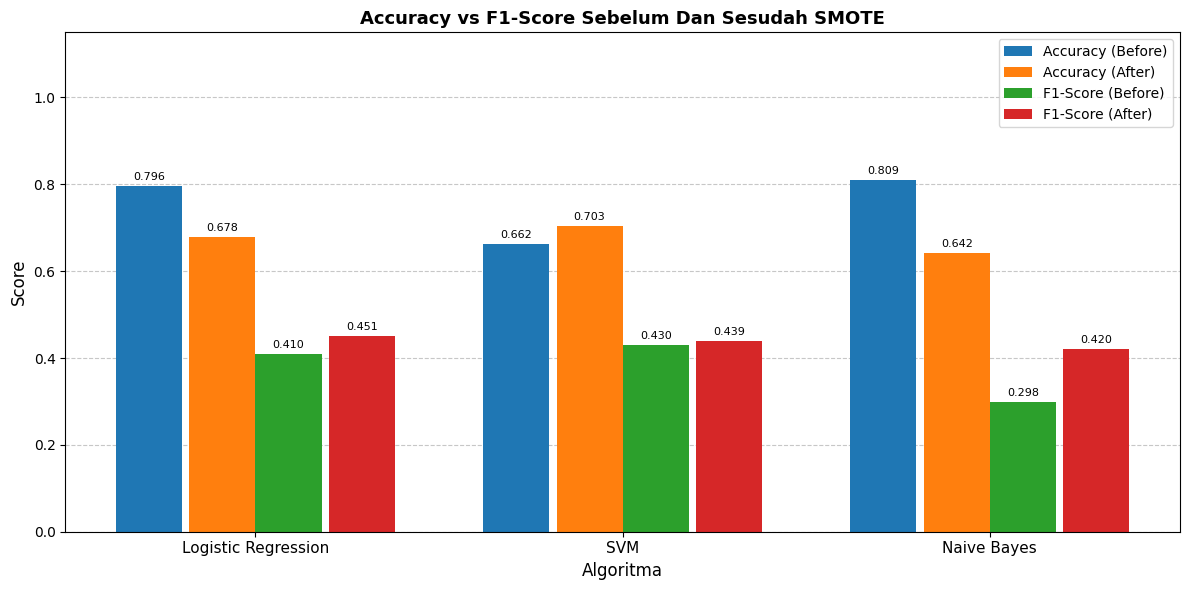

✅ Grafik disimpan: perbandingan_accuracy_f1_smote.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data dari hasil evaluasi yang sudah ada
nama_model_plot  = ['Logistic Regression', 'SVM', 'Naive Bayes']

acc_before  = [hasil_lr_sbl['accuracy'],  hasil_svm_sbl['accuracy'],  hasil_nb_sbl['accuracy']]
acc_after   = [hasil_lr_smt['accuracy'],  hasil_svm_smt['accuracy'],  hasil_nb_smt['accuracy']]
f1_before   = [hasil_lr_sbl['f1_score'],  hasil_svm_sbl['f1_score'],  hasil_nb_sbl['f1_score']]
f1_after    = [hasil_lr_smt['f1_score'],  hasil_svm_smt['f1_score'],  hasil_nb_smt['f1_score']]

x      = np.arange(len(nama_model_plot))
lebar  = 0.18  # lebar tiap batang
gap    = 0.02  # jarak antar kelompok batang

fig, ax = plt.subplots(figsize=(12, 6))

# 4 batang per algoritma — persis seperti jurnal
bar1 = ax.bar(x - lebar*1.5 - gap, acc_before, lebar, label='Accuracy (Before)', color='#1f77b4')
bar2 = ax.bar(x - lebar*0.5,       acc_after,  lebar, label='Accuracy (After)',  color='#ff7f0e')
bar3 = ax.bar(x + lebar*0.5,       f1_before,  lebar, label='F1-Score (Before)', color='#2ca02c')
bar4 = ax.bar(x + lebar*1.5 + gap, f1_after,   lebar, label='F1-Score (After)',  color='#d62728')

# Tambahkan angka di atas setiap batang
def label_bar(bars):
    for bar in bars:
        tinggi = bar.get_height()
        ax.annotate(
            f'{tinggi:.3f}',
            xy=(bar.get_x() + bar.get_width() / 2, tinggi),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=8
        )

label_bar(bar1)
label_bar(bar2)
label_bar(bar3)
label_bar(bar4)

# Konfigurasi tampilan
ax.set_xlabel('Algoritma', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Accuracy vs F1-Score Sebelum Dan Sesudah SMOTE', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(nama_model_plot, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('perbandingan_accuracy_f1_smote.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Grafik disimpan: perbandingan_accuracy_f1_smote.png")
files.download('perbandingan_accuracy_f1_smote.png')

##SIMPAN HASIL

In [ ]:
import os
import pickle
import shutil
from google.colab import files

In [ ]:
output_folder = "hasil_model"

# Jika folder sudah ada, hapus dulu agar isinya bersih
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

os.makedirs(output_folder)

print(f"Folder dibuat: {output_folder}")

# SIMPAN TABEL PERBANDINGAN
tabel_path = os.path.join(output_folder, "tabel_perbandingan_algoritma.csv")
tabel_perbandingan.to_csv(tabel_path, index=False)
print("File disimpan:", tabel_path)

# SIMPAN SEMUA MODEL
model_files = {
    "model_logistic_regression.pkl": model_lr,
    "model_svm.pkl": model_svm,
    "model_naive_bayes.pkl": model_nb,
    "tfidf_vectorizer.pkl": tfidf,
    "label_encoder.pkl": label_encoder
}

for filename, object_model in model_files.items():
    file_path = os.path.join(output_folder, filename)
    with open(file_path, "wb") as f:
        pickle.dump(object_model, f)
    print("File disimpan:", file_path)

# PINDAHKAN FILE VISUALISASI KE FOLDER OUTPUT
visualisasi_files = [
    "confusion_matrix_Logistic_Regression.png",
    "confusion_matrix_SVM.png",
    "confusion_matrix_Naive_Bayes.png",
    "perbandingan_algoritma.png"
]

for filename in visualisasi_files:
    if os.path.exists(filename):
        tujuan = os.path.join(output_folder, filename)
        shutil.copy(filename, tujuan)
        print("File visualisasi disalin:", tujuan)
    else:
        print("File tidak ditemukan, dilewati:", filename)

# BUAT ZIP DARI FOLDER OUTPUT
zip_filename = "hasil_model"

# Jika file ZIP lama sudah ada, hapus dulu
if os.path.exists(zip_filename + ".zip"):
    os.remove(zip_filename + ".zip")

shutil.make_archive(zip_filename, "zip", output_folder)

print("\n" + "=" * 55)
print("  RINGKASAN FILE UNTUK WEBSITE")
print("=" * 55)
print("  Folder output       :", output_folder)
print("  Model klasifikasi   : 3 file (.pkl)")
print("  Preprocessing       : tfidf_vectorizer.pkl, label_encoder.pkl")
print("  Tabel evaluasi      : tabel_perbandingan_algoritma.csv")
print("  Visualisasi         : 3 confusion matrix + 1 bar chart")
print("  File ZIP            :", zip_filename + ".zip")
print("=" * 55)

print("\nSELESAI: semua file sudah dimasukkan ke satu folder dan dibuat ZIP.")

# DOWNLOAD 1 FILE ZIP SAJA
files.download(zip_filename + ".zip")

Folder dibuat: hasil_model
File disimpan: hasil_model/tabel_perbandingan_algoritma.csv
File disimpan: hasil_model/model_logistic_regression.pkl
File disimpan: hasil_model/model_svm.pkl
File disimpan: hasil_model/model_naive_bayes.pkl
File disimpan: hasil_model/tfidf_vectorizer.pkl
File disimpan: hasil_model/label_encoder.pkl
File visualisasi disalin: hasil_model/confusion_matrix_Logistic_Regression.png
File visualisasi disalin: hasil_model/confusion_matrix_SVM.png
File visualisasi disalin: hasil_model/confusion_matrix_Naive_Bayes.png
File visualisasi disalin: hasil_model/perbandingan_algoritma.png

  RINGKASAN FILE UNTUK WEBSITE
  Folder output       : hasil_model
  Model klasifikasi   : 3 file (.pkl)
  Preprocessing       : tfidf_vectorizer.pkl, label_encoder.pkl
  Tabel evaluasi      : tabel_perbandingan_algoritma.csv
  Visualisasi         : 3 confusion matrix + 1 bar chart
  File ZIP            : hasil_model.zip

SELESAI: semua file sudah dimasukkan ke satu folder dan dibuat ZIP.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
with open('model_balanced_random_forest.pkl', 'wb') as f:
    pickle.dump(model_brf, f)
print("✅ File disimpan: model_balanced_random_forest.pkl")

from google.colab import files
files.download('model_balanced_random_forest.pkl')